<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2672/4070673174.py:48: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Eigenvalue $\lambda$', fontsize=12)


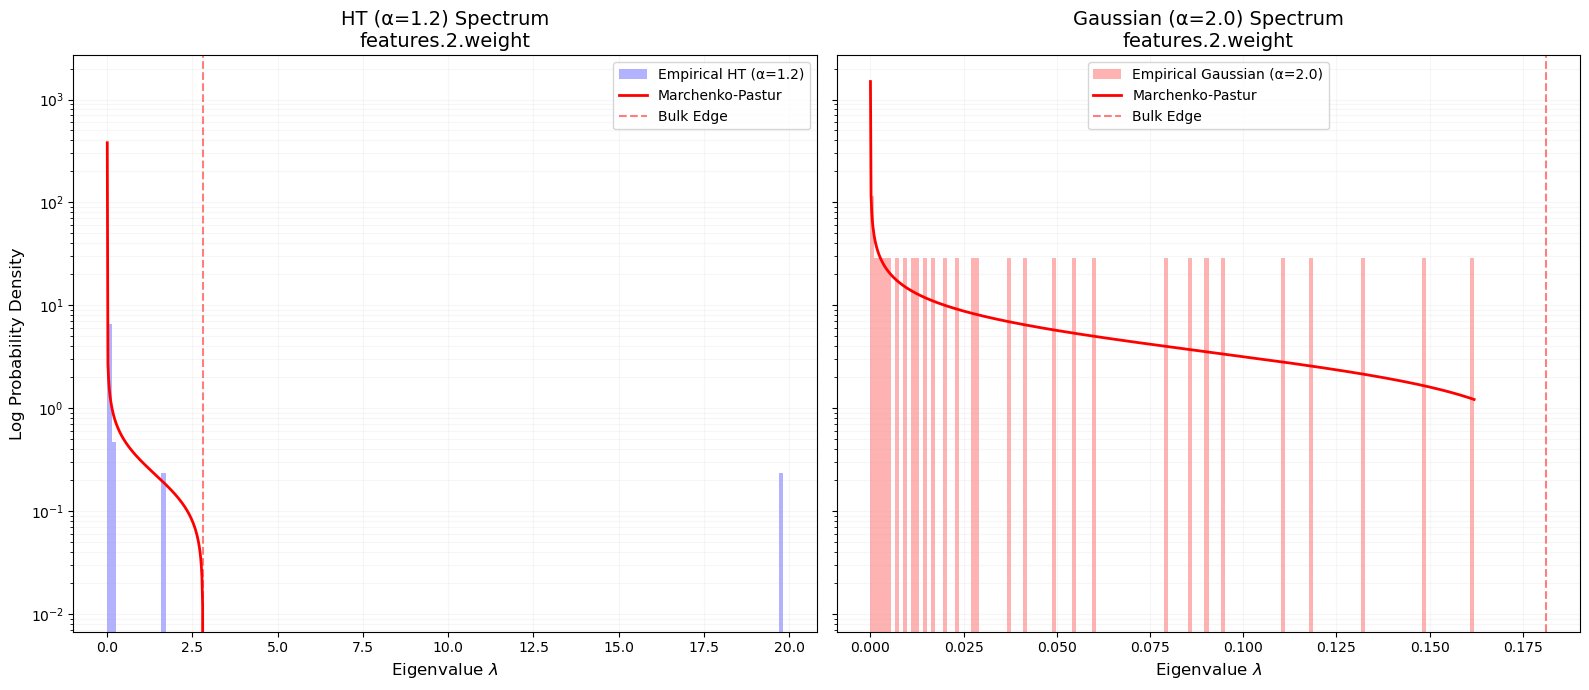

HT Max Eigenvalue: 19.8199
Gaussian Max Eigenvalue: 0.1619


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src import get_singular_values, marchenko_pastur_pdf

# 1. Config & Paths
HT_PATH = Path("training_runs/mlp32_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_113516_s0")
GAUSS_PATH = Path("training_runs/mlp32_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_113641_s0")
LAYER_KEY = 'features.2.weight'

def load_and_compute(path, key):
    checkpoint = torch.load(path / "final_model.pth", map_location='cpu')
    state_dict = checkpoint.get('model_state', checkpoint)
    weights = state_dict[key].float()
    evs = get_singular_values(weights)
    return evs, weights.shape

# 2. Get Data
evs_ht, shape_ht = load_and_compute(HT_PATH, LAYER_KEY)
evs_ga, shape_ga = load_and_compute(GAUSS_PATH, LAYER_KEY)

# 3. Combined Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
data = [(evs_ht, shape_ht, 'HT (α=1.2)', 'blue'),
        (evs_ga, shape_ga, 'Gaussian (α=2.0)', 'red')]

for i, (evs, (N, M), label, color) in enumerate(data):
    ax = axes[i]
    Q = N / M
    sigma_est = np.sqrt(np.mean(evs))

    # Empirical Histogram
    counts, bins, _ = ax.hist(evs, bins=150, density=True, alpha=0.3,
                              color=color, label=f'Empirical {label}')

    # MP Law Theory
    x_range = np.linspace(1e-6, np.max(bins), 1000)
    pdf, l_min, l_max = marchenko_pastur_pdf(x_range, Q, sigma=sigma_est)
    ax.plot(x_range, pdf, color='red', lw=2, label='Marchenko-Pastur')

    # Bulk Edge Annotation
    ax.axvline(l_max, color='red', linestyle='--', alpha=0.5, label='Bulk Edge')

    # Aesthetics
    ax.set_yscale('log')
    ax.set_title(f"{label} Spectrum\n{LAYER_KEY}", fontsize=14)
    ax.set_xlabel('Eigenvalue $\lambda$', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.1)
    ax.legend()

axes[0].set_ylabel('Log Probability Density', fontsize=12)
plt.tight_layout()
plt.show()

print(f"HT Max Eigenvalue: {np.max(evs_ht):.4f}")
print(f"Gaussian Max Eigenvalue: {np.max(evs_ga):.4f}")

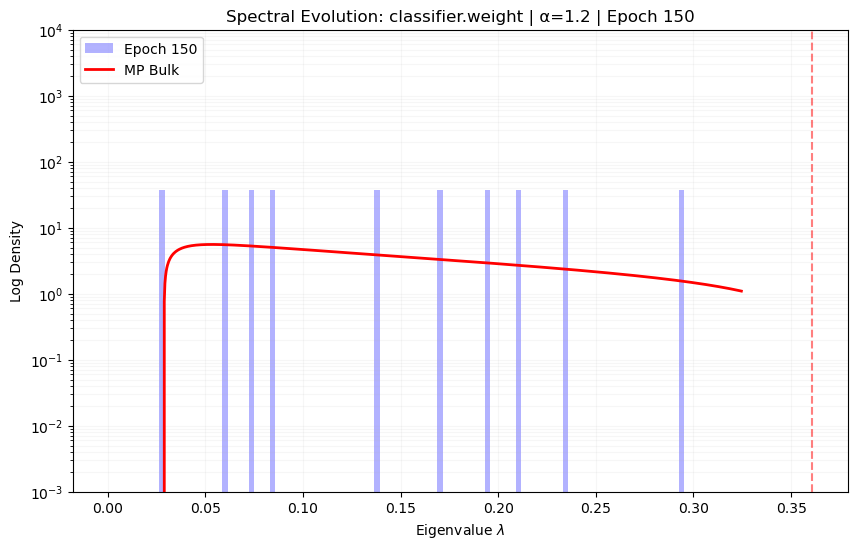

Relative Weight Displacement: 1.185388
Top Eigenvalue Shift: 0.157557


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src import get_singular_values, marchenko_pastur_pdf
from IPython.display import clear_output, display

# 1. Config
RUN_DIR = Path("training_runs/mlp32_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_113516_s0")
LAYER_KEY = 'classifier.weight'
EPOCHS = range(0, 160, 10)  # Matches your saving frequency

def get_evs_from_epoch(epoch):
    path = RUN_DIR / "checkpoints" / f"weights_epoch_{epoch}.pth"
    state_dict = torch.load(path)
    weights = state_dict[LAYER_KEY]
    return get_singular_values(weights), weights.shape

# 2. Manual Loop for Notebooks
for epoch in EPOCHS:
    try:
        # Load weights
        path = RUN_DIR / "checkpoints" / f"weights_epoch_{epoch}.pth"
        if not path.exists():
            print(f"Skipping {epoch}: Path not found.")
            continue

        state_dict = torch.load(path)
        weights = state_dict[LAYER_KEY]
        evs = get_singular_values(weights)
        N, M = weights.shape
        Q = N / M

        # Plotting
        clear_output(wait=True) # Clears the previous plot for the "animation" effect
        plt.figure(figsize=(10, 6))

        # Empirical
        plt.hist(evs, bins=100, density=True, alpha=0.3, color='blue', label=f'Epoch {epoch}')

        # Theoretical MP
        sigma_est = np.sqrt(np.mean(evs))
        x_max_plot = np.max(evs) * 1.1
        x_range = np.linspace(1e-4, x_max_plot, 1000)
        pdf, _, l_max = marchenko_pastur_pdf(x_range, Q, sigma=sigma_est)

        plt.plot(x_range, pdf, 'r-', lw=2, label='MP Bulk')
        plt.axvline(l_max, color='red', linestyle='--', alpha=0.5)

        # Scaling
        plt.yscale('log')
        plt.ylim(1e-3, 1e4)
        plt.title(f"Spectral Evolution: {LAYER_KEY} | α=1.2 | Epoch {epoch}")
        plt.xlabel("Eigenvalue $\lambda$")
        plt.ylabel("Log Density")
        plt.legend()
        plt.grid(True, which='both', alpha=0.1)

        display(plt.gcf()) # Explicitly show the figure
        plt.close() # Close to free memory

    except Exception as e:
        print(f"Error at epoch {epoch}: {e}")

# Compare Epoch 0 to Epoch 150
W_init = torch.load(RUN_DIR / "checkpoints/weights_epoch_0.pth")[LAYER_KEY]
W_final = torch.load(RUN_DIR / "checkpoints/weights_epoch_150.pth")[LAYER_KEY]

# 1. Check weight displacement
dist = torch.norm(W_final - W_init) / torch.norm(W_init)
print(f"Relative Weight Displacement: {dist.item():.6f}")

# 2. Check the Top Outlier movement
evs_0 = get_singular_values(W_init)
evs_150 = get_singular_values(W_final)

shift = np.max(evs_150) - np.max(evs_0)
print(f"Top Eigenvalue Shift: {shift:.6f}")

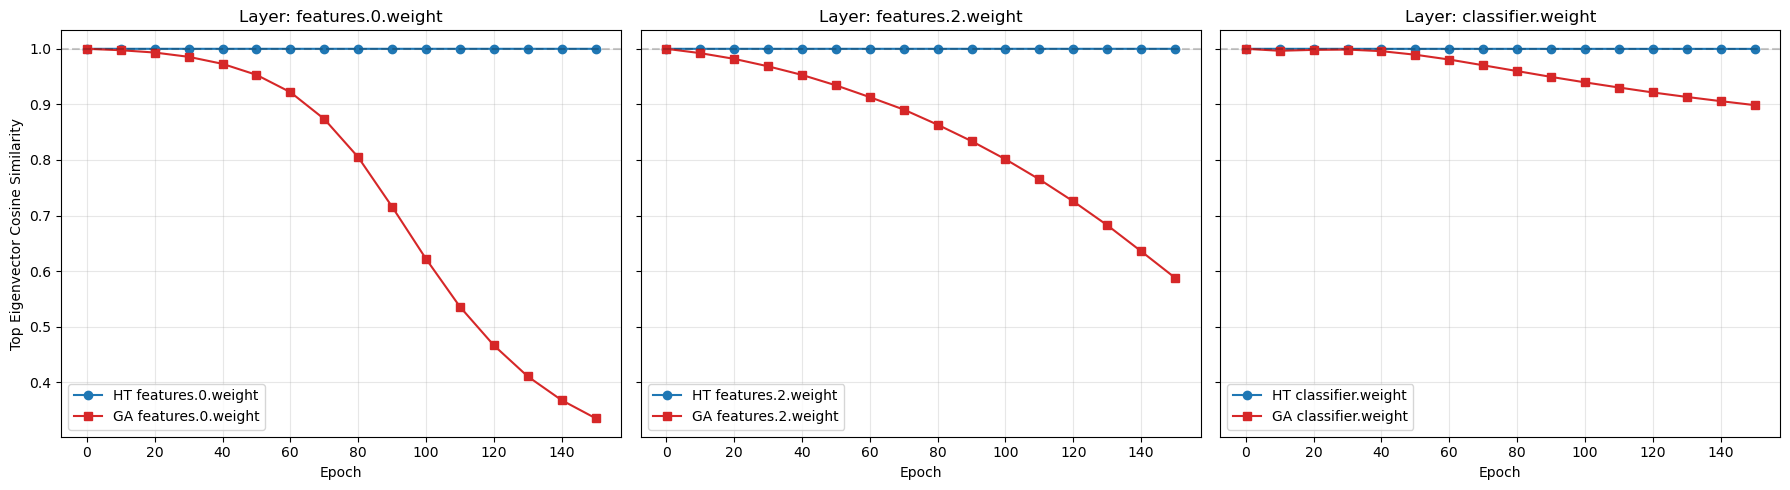

In [28]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Paths based on your new 32-width runs
HT_DIR = Path("training_runs/mlp784_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260221_130323_s0")
GA_DIR = Path("training_runs/mlp784_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260221_130451_s0")

LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']
EPOCHS = range(0, 160, 10)

def get_layer_rotations(run_dir, layers, epochs):
    results = {layer: [] for layer in layers}

    for layer in layers:
        # Load Initial State for this specific layer
        state_0 = torch.load(run_dir / "checkpoints/weights_epoch_0.pth")
        W0 = state_0[layer].detach().cpu().float()
        # Ensure we handle the matrix orientation correctly for SVD
        _, _, Vt0 = torch.svd(W0)
        v0 = Vt0[:, 0] # Tracking only the Top-1 Eigenvector for clarity

        layer_sims = []
        for epoch in epochs:
            path = run_dir / "checkpoints" / f"weights_epoch_{epoch}.pth"
            Wt = torch.load(path)[layer].detach().cpu().float()
            _, _, Vtt = torch.svd(Wt)
            vt = Vtt[:, 0]

            similarity = torch.abs(torch.dot(v0, vt))
            layer_sims.append(similarity.item())
        results[layer] = layer_sims
    return results

# Process both runs
ht_results = get_layer_rotations(HT_DIR, LAYERS, EPOCHS)
ga_results = get_layer_rotations(GA_DIR, LAYERS, EPOCHS)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = {'HT': '#1f77b4', 'GA': '#d62728'}

for i, layer in enumerate(LAYERS):
    axes[i].plot(EPOCHS, ht_results[layer], color=colors['HT'], marker='o', label=f'HT {layer}')
    axes[i].plot(EPOCHS, ga_results[layer], color=colors['GA'], marker='s', label=f'GA {layer}')

    axes[i].axhline(1.0, color='black', alpha=0.2, linestyle='--')
    axes[i].set_title(f"Layer: {layer}")
    axes[i].set_xlabel("Epoch")
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel("Top Eigenvector Cosine Similarity")
    axes[i].legend()

plt.tight_layout()
plt.show()

Analyzing Spectral Sensitivity for Layer: features.0.weight
K=0 | HT Acc: 0.9701 | GA Acc: 0.9718
K=1 | HT Acc: 0.8766 | GA Acc: 0.9172
K=2 | HT Acc: 0.7934 | GA Acc: 0.7956
K=3 | HT Acc: 0.7462 | GA Acc: 0.7745
K=4 | HT Acc: 0.6684 | GA Acc: 0.7569
K=5 | HT Acc: 0.5815 | GA Acc: 0.6815
K=6 | HT Acc: 0.4899 | GA Acc: 0.5197
K=7 | HT Acc: 0.4070 | GA Acc: 0.3313
K=8 | HT Acc: 0.2024 | GA Acc: 0.2393
K=9 | HT Acc: 0.1966 | GA Acc: 0.1876
K=10 | HT Acc: 0.0980 | GA Acc: 0.0980


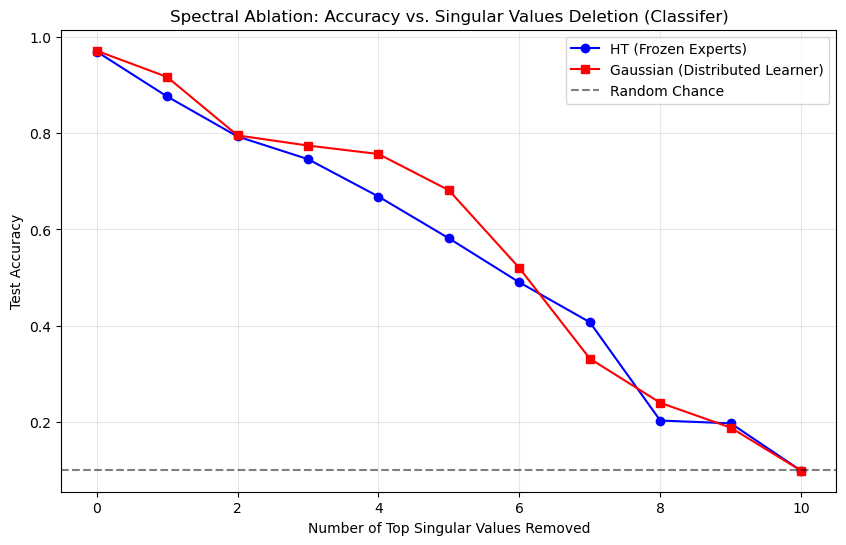

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src import GeneralMLP # Uses your provided architecture

# --- 1. Data Setup (Universal MNIST) ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

# --- 2. Ablation Core Logic ---
def get_ablated_accuracy(checkpoint_path, layer_key, k_to_remove):
    # Instantiate model to match your 32-width configuration
    # Based on architectures.py: GeneralMLP(input_size, hidden_size, num_classes, depth)
    model = GeneralMLP(input_size=784, hidden_size=784, num_classes=10, depth=2, activation_name='tanh', bias=False)

    checkpoint = torch.load(checkpoint_path)
    # Check if nested in 'model_state' based on ml_library.py export
    state_dict = checkpoint.get('model_state', checkpoint)
    model.load_state_dict(state_dict)

    # Isolate Target Weight Matrix
    W = state_dict[layer_key].detach().cpu().float()
    U, S, V = torch.svd(W)

    # Zero out Top-K Singular Values
    S_mod = S.clone()
    S_mod[:k_to_remove] = 0.0

    # Reconstruct: W = U @ diag(S) @ V.T
    W_new = U @ torch.diag(S_mod) @ V.t()

    # Inject back into model (Direct attribute access for features.0.weight)
    with torch.no_grad():
        if layer_key == 'features.0.weight':
            model.features[0].weight.copy_(W_new)
        elif layer_key == 'features.2.weight':
            model.features[2].weight.copy_(W_new)
        elif layer_key == 'classifier.weight':
            model.classifier.weight.copy_(W_new)

    # Validate
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            output = model(imgs)
            correct += (output.argmax(1) == lbls).sum().item()

    return correct / len(test_set)

# --- 2. Low-Rank (Top-K Only) Logic ---
def get_low_rank_accuracy(checkpoint_path, layer_key, k_to_keep):
    # Instantiate based on your architectures.py and 32-width config
    model = GeneralMLP(input_size=784, hidden_size=784, num_classes=10, depth=2,
                       activation_name='tanh', bias=False)

    checkpoint = torch.load(checkpoint_path)
    state_dict = checkpoint.get('model_state', checkpoint)
    model.load_state_dict(state_dict)

    # Isolate Target Weight Matrix
    W = state_dict[layer_key].detach().cpu().float()
    U, S, V = torch.svd(W)

    # --- THE INVERSION ---
    # Keep only the first k_to_keep components; zero out the rest (the bulk)
    S_mod = S.clone()
    S_mod[k_to_keep:] = 0.0

    # Reconstruct: W = U @ diag(S) @ V.T
    W_new = U @ torch.diag(S_mod) @ V.t()

    # Inject back into model
    with torch.no_grad():
        if 'features' in layer_key:
            layer_idx = int(layer_key.split('.')[1])
            model.features[layer_idx].weight.copy_(W_new)
        elif 'classifier' in layer_key:
            model.classifier.weight.copy_(W_new)

    # Validate on MNIST
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            output = model(imgs)
            correct += (output.argmax(1) == lbls).sum().item()

    return correct / len(test_set)

# --- 3. Run Comparison (Width-32 Path) ---
HT_RUN = Path("training_runs/mlp784_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260221_130323_s0/final_model.pth")
GA_RUN = Path("training_runs/mlp784_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260221_130451_s0/final_model.pth")

k_range = range(0, 11) # Test removing 0 to 10 top singular values
ht_results, ga_results = [], []

print(f"Analyzing Spectral Sensitivity for Layer: features.0.weight")
for k in k_range:
    ht_acc = get_ablated_accuracy(HT_RUN, 'classifier.weight', k)
    ga_acc = get_ablated_accuracy(GA_RUN, 'classifier.weight', k)
    ht_results.append(ht_acc)
    ga_results.append(ga_acc)
    print(f"K={k} | HT Acc: {ht_acc:.4f} | GA Acc: {ga_acc:.4f}")

# --- 4. Plotting the "Symmetry Breaking" ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, ht_results, 'b-o', label='HT (Frozen Experts)')
plt.plot(k_range, ga_results, 'r-s', label='Gaussian (Distributed Learner)')
plt.axhline(0.1, color='black', linestyle='--', alpha=0.5, label='Random Chance')
plt.title("Spectral Ablation: Accuracy vs. Singular Values Deletion (Classifer)")
plt.xlabel("Number of Top Singular Values Removed")
plt.ylabel("Test Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import torch
import pandas as pd
from pathlib import Path

def calculate_metrics(W):
    """Calculates IPR of the top eigenvector and Effective Rank of the matrix."""
    W = W.detach().cpu().float()
    U, S, V = torch.svd(W)

    # 1. Inverse Participation Ratio (IPR) of Top Right Singular Vector
    # Measures localization: 1/N = fully delocalized, 1.0 = localized on one pixel
    v_top = V[:, 0]
    ipr = torch.sum(v_top**4) / (torch.sum(v_top**2)**2)

    # 2. Effective Rank (Stable Rank)
    # Measures the 'dimensionality' of the matrix: ||W||_F^2 / ||W||_2^2
    effective_rank = (torch.sum(S**2)) / (S[0]**2)

    return ipr.item(), effective_rank.item(), S.numpy()

def analyze_run(run_path, layers):
    checkpoint = torch.load(run_path / "final_model.pth", map_location='cpu')
    state_dict = checkpoint.get('model_state', checkpoint)

    results = []
    for layer in layers:
        ipr, eff_rank, _ = calculate_metrics(state_dict[layer])
        results.append({
            'layer': layer,
            'IPR': ipr,
            'Effective_Rank': eff_rank
        })
    return pd.DataFrame(results)

# Paths for your 32-width runs
HT_RUN = Path("training_runs/mlp32_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_113516_s0")
GA_RUN = Path("training_runs/mlp32_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_113641_s0")
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']

ht_df = analyze_run(HT_RUN, LAYERS)
ga_df = analyze_run(GA_RUN, LAYERS)

print("--- HT Model Metrics ---")
print(ht_df)
print("\n--- Gaussian Model Metrics ---")
print(ga_df)

--- HT Model Metrics ---
               layer       IPR  Effective_Rank
0  features.0.weight  0.954183        2.861837
1  features.2.weight  0.999206        1.132317
2  classifier.weight  0.304204        5.032941

--- Gaussian Model Metrics ---
               layer       IPR  Effective_Rank
0  features.0.weight  0.003975       21.535532
1  features.2.weight  0.082585        8.955302
2  classifier.weight  0.071470        6.004311
